In [1]:
import pandas as pd
from helpers import summarize_columns

df = pd.read_parquet("datasets/crash_data.parquet", engine="pyarrow")
summarize_columns(df)

                             name           dtype   unique  size (MB)
0                    COLLISION_ID           int64  2002412         15
1                         BOROUGH             str        5         29
2                        LATITUDE         float64   130276         15
3                       LONGITUDE         float64   101069         15
4                  CRASH DATETIME  datetime64[us]  1184390         15
5       NUMBER OF PERSONS INJURED            Int8       31          3
6        NUMBER OF PERSONS KILLED            Int8        8          3
7   NUMBER OF PEDESTRIANS INJURED            Int8       14          3
8    NUMBER OF PEDESTRIANS KILLED            Int8        6          3
9       NUMBER OF CYCLIST INJURED            Int8        5          3
10       NUMBER OF CYCLIST KILLED            Int8        3          3
11     NUMBER OF MOTORIST INJURED            Int8       29          3
12      NUMBER OF MOTORIST KILLED            Int8        6          3
13  CONTRIBUTING FAC

In [2]:
# --- Filtering in lethal cases --- #
df = df[df["NUMBER OF PERSONS KILLED"].notna() & df["NUMBER OF PERSONS KILLED"] != 0]

# --- Loading the person dataset and joining it with crash dataset via COLLISION_ID --- #
pers_df = pd.read_parquet("datasets/person_data.parquet", engine="pyarrow")

merg_df = df.merge(pers_df, on="COLLISION_ID", how="inner")

del df, pers_df
#  summarize_columns(merg_df)

In [3]:
merg_df

,COLLISION_ID,BOROUGH,LATITUDE,LONGITUDE,CRASH DATETIME,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,...,POSITION_IN_VEHICLE,SAFETY_EQUIPMENT,PED_LOCATION,PED_ACTION,COMPLAINT,PED_ROLE,CONTRIBUTING_FACTOR_1,CONTRIBUTING_FACTOR_2,PERSON_SEX,CRASH_DATETIME
0,4456659,Queens,40.720535,-73.888850,2021-07-09 00:43:00,0,1,0,1,0,...,NaN,NaN,NaN,NaN,NaN,Registrant,NaN,NaN,NaN,2021-07-09 00:43:00
1,4456659,Queens,40.720535,-73.888850,2021-07-09 00:43:00,0,1,0,1,0,...,NaN,NaN,NaN,NaN,NaN,Driver,NaN,NaN,NaN,2021-07-09 00:43:00
2,4456659,Queens,40.720535,-73.888850,2021-07-09 00:43:00,0,1,0,1,0,...,NaN,NaN,Not At Intersection,Other Actions in Roadway,Crush Injuries,Pedestrian,Pedestrian/Bicyclist/Other Pedestrian Error/Co...,Unspecified,F,2021-07-09 00:43:00
3,4456659,Queens,40.720535,-73.888850,2021-07-09 00:43:00,0,1,0,1,0,...,Driver,Lap Belt & Harness,NaN,NaN,Does Not Apply,Driver,NaN,NaN,M,2021-07-09 00:43:00
4,4456659,Queens,40.720535,-73.888850,2021-07-09 00:43:00,0,1,0,1,0,...,NaN,NaN,NaN,NaN,NaN,Notified Person,NaN,NaN,NaN,2021-07-09 00:43:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11819,4487497,Staten Island,40.547924,-74.166954,2021-12-17 23:50:00,1,1,0,0,0,...,Driver,NaN,NaN,NaN,Crush Injuries,Driver,NaN,NaN,M,2021-12-17 23:50:00
11820,4487497,Staten Island,40.547924,-74.166954,2021-12-17 23:50:00,1,1,0,0,0,...,NaN,NaN,NaN,NaN,NaN,Notified Person,NaN,NaN,NaN,2021-12-17 23:50:00
11821,4487497,Staten Island,40.547924,-74.166954,2021-12-17 23:50:00,1,1,0,0,0,...,NaN,NaN,NaN,NaN,NaN,Registrant,NaN,NaN,F,2021-12-17 23:50:00
11822,4487497,Staten Island,40.547924,-74.166954,2021-12-17 23:50:00,1,1,0,0,0,...,"Front passenger, if two or more persons, inclu...",Lap Belt & Harness,NaN,NaN,Complaint of Pain or Nausea,Passenger,NaN,NaN,M,2021-12-17 23:50:00


## Data Filtering and cleaning

In [4]:
# --- One crash (df) → many persons (pers_df) via COLLISION_ID. The crash-level
#     "NUMBER OF PERSONS KILLED" filter keeps every occupant from a fatal crash,
#     including survivors. Filter at the person level with PERSON_INJURY to count
#     actual deaths. Restrict to cis-gender occupants for the sex breakdown. --- #
merg_df = merg_df[
    merg_df["PERSON_SEX"].isin(["M", "F"])
    & merg_df["PERSON_TYPE"].isin(["Occupant"])
    & (merg_df["PERSON_INJURY"] == "Killed")
]

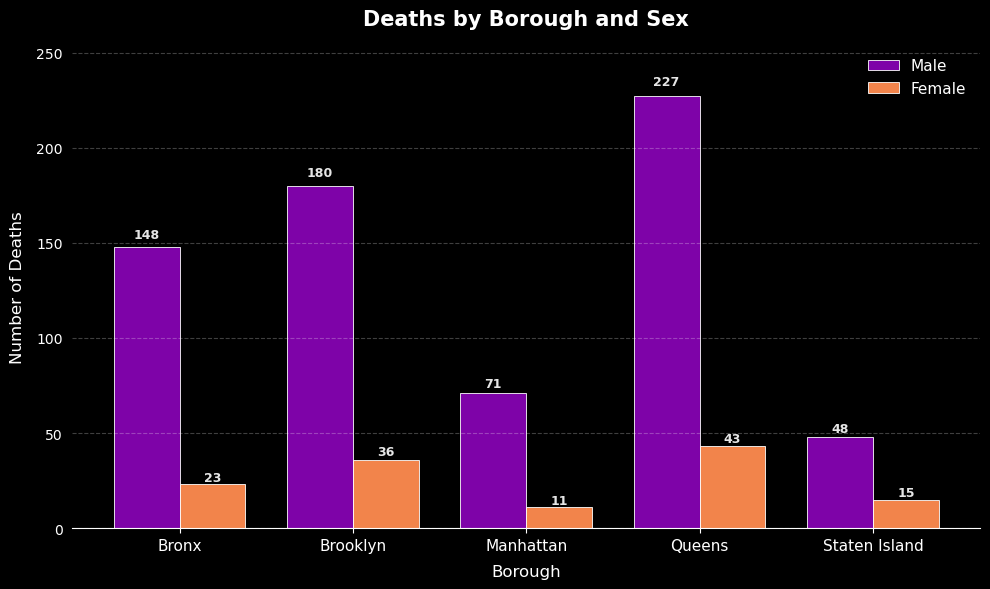

In [5]:
import matplotlib.pyplot as plt


counts = (
    merg_df.groupby(["BOROUGH", "PERSON_SEX"]).size().unstack(fill_value=0)[["M", "F"]]
)

male_color = plt.cm.plasma(0.25)
female_color = plt.cm.plasma(0.70)

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(10, 6))
    x = range(len(counts))
    w = 0.38

    bars_m = ax.bar(
        [i - w / 2 for i in x],
        counts["M"],
        w,
        label="Male",
        color=male_color,
        edgecolor="white",
        linewidth=0.6,
    )
    bars_f = ax.bar(
        [i + w / 2 for i in x],
        counts["F"],
        w,
        label="Female",
        color=female_color,
        edgecolor="white",
        linewidth=0.6,
    )

    for bars in (bars_m, bars_f):
        for bar in bars:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h * 1.02,
                f"{int(h):,}",
                ha="center",
                va="bottom",
                fontsize=9,
                color="white",
                alpha=0.9,
                fontweight="bold",
            )

    ax.set_xticks(list(x))
    ax.set_xticklabels(counts.index, fontsize=11)
    ax.set_xlabel("Borough", fontsize=12, labelpad=8)
    ax.set_ylabel("Number of Deaths", fontsize=12, labelpad=8)
    ax.set_title("Deaths by Borough and Sex", fontsize=15, fontweight="bold", pad=14)
    ax.set_ylim(0, counts.values.max() * 1.12)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(left=False)
    ax.legend(frameon=False, fontsize=11, loc="upper right")

    plt.tight_layout()
    plt.show()

## Exploring sex differences among fatal occupants

Each killed occupant is one row in `merg_df` (1:N join from crash → persons). Below
we slice that person-level table by `PERSON_SEX` to look at *who* dies — age,
seating role, and time of day — not just *where*.

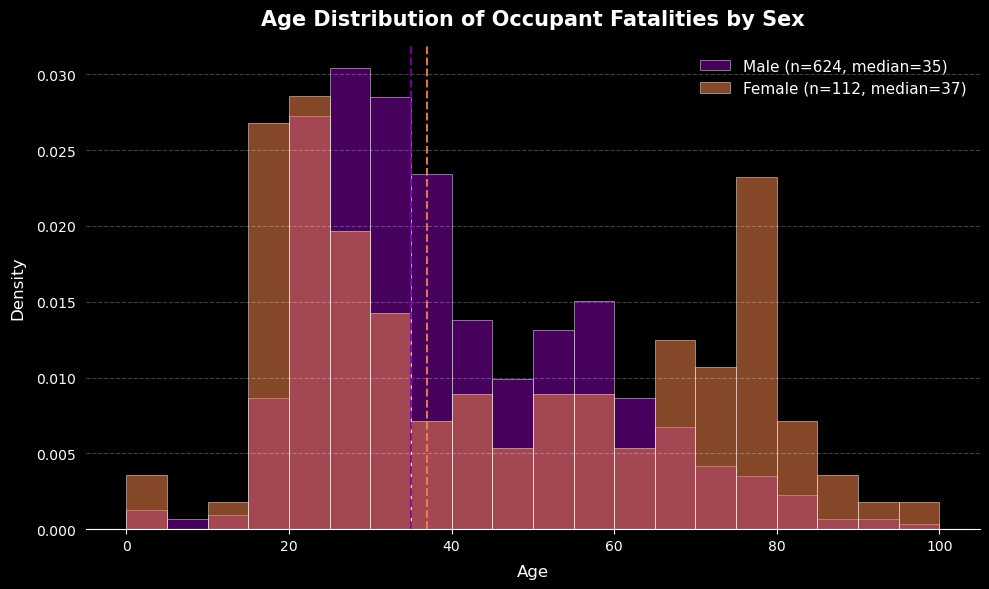

In [6]:
import numpy as np
import matplotlib.pyplot as plt

ages_m = merg_df.loc[merg_df["PERSON_SEX"] == "M", "PERSON_AGE"].dropna().astype(float)
ages_f = merg_df.loc[merg_df["PERSON_SEX"] == "F", "PERSON_AGE"].dropna().astype(float)

male_color = plt.cm.plasma(0.25)
female_color = plt.cm.plasma(0.70)
bins = np.arange(0, 101, 5)

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.hist(
        ages_m, bins=bins, density=True, alpha=0.55, color=male_color,
        label=f"Male (n={len(ages_m):,}, median={ages_m.median():.0f})",
        edgecolor="white", linewidth=0.6,
    )
    ax.hist(
        ages_f, bins=bins, density=True, alpha=0.55, color=female_color,
        label=f"Female (n={len(ages_f):,}, median={ages_f.median():.0f})",
        edgecolor="white", linewidth=0.6,
    )
    ax.axvline(ages_m.median(), color=male_color, linestyle="--", linewidth=1.5, alpha=0.9)
    ax.axvline(ages_f.median(), color=female_color, linestyle="--", linewidth=1.5, alpha=0.9)

    ax.set_xlabel("Age", fontsize=12, labelpad=8)
    ax.set_ylabel("Density", fontsize=12, labelpad=8)
    ax.set_title("Age Distribution of Occupant Fatalities by Sex", fontsize=15, fontweight="bold", pad=14)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.tick_params(left=False)
    ax.legend(frameon=False, fontsize=11, loc="upper right")

    plt.tight_layout()
    plt.show()

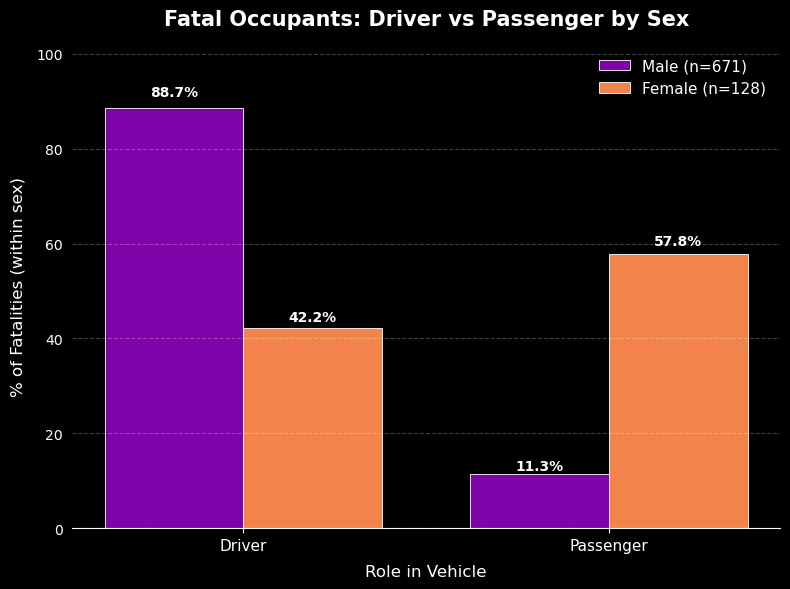

In [7]:
import matplotlib.pyplot as plt

roles = ["Driver", "Passenger"]
role_df = merg_df[merg_df["PED_ROLE"].isin(roles)]
ct = (
    role_df.groupby(["PED_ROLE", "PERSON_SEX"], observed=True)
    .size()
    .unstack(fill_value=0)
    .loc[roles, ["M", "F"]]
)
prop = ct.div(ct.sum(axis=0), axis=1) * 100  # share within each sex

male_color = plt.cm.plasma(0.25)
female_color = plt.cm.plasma(0.70)

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(8, 6))
    x = range(len(roles))
    w = 0.38

    bars_m = ax.bar(
        [i - w / 2 for i in x], prop["M"], w,
        label=f"Male (n={ct['M'].sum():,})", color=male_color,
        edgecolor="white", linewidth=0.6,
    )
    bars_f = ax.bar(
        [i + w / 2 for i in x], prop["F"], w,
        label=f"Female (n={ct['F'].sum():,})", color=female_color,
        edgecolor="white", linewidth=0.6,
    )

    for bars in (bars_m, bars_f):
        for bar in bars:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2, h * 1.02,
                f"{h:.1f}%", ha="center", va="bottom",
                fontsize=10, color="white", fontweight="bold",
            )

    ax.set_xticks(list(x))
    ax.set_xticklabels(roles, fontsize=11)
    ax.set_xlabel("Role in Vehicle", fontsize=12, labelpad=8)
    ax.set_ylabel("% of Fatalities (within sex)", fontsize=12, labelpad=8)
    ax.set_title("Fatal Occupants: Driver vs Passenger by Sex", fontsize=15, fontweight="bold", pad=14)
    ax.set_ylim(0, max(prop.values.max() * 1.15, 100))
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.tick_params(left=False)
    ax.legend(frameon=False, fontsize=11, loc="upper right")

    plt.tight_layout()
    plt.show()

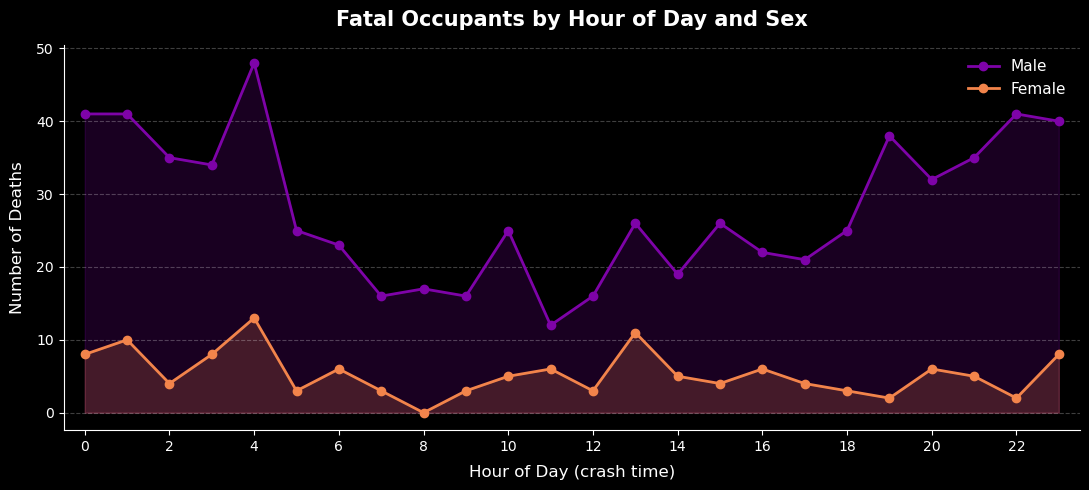

In [8]:
import matplotlib.pyplot as plt

hours = merg_df["CRASH DATETIME"].dt.hour
hourly = (
    merg_df.assign(hour=hours)
    .groupby(["hour", "PERSON_SEX"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(range(24), fill_value=0)[["M", "F"]]
)

male_color = plt.cm.plasma(0.25)
female_color = plt.cm.plasma(0.70)

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(11, 5))

    ax.plot(hourly.index, hourly["M"], marker="o", color=male_color, label="Male", linewidth=2)
    ax.plot(hourly.index, hourly["F"], marker="o", color=female_color, label="Female", linewidth=2)
    ax.fill_between(hourly.index, hourly["M"], color=male_color, alpha=0.2)
    ax.fill_between(hourly.index, hourly["F"], color=female_color, alpha=0.2)

    ax.set_xticks(range(0, 24, 2))
    ax.set_xlim(-0.5, 23.5)
    ax.set_xlabel("Hour of Day (crash time)", fontsize=12, labelpad=8)
    ax.set_ylabel("Number of Deaths", fontsize=12, labelpad=8)
    ax.set_title("Fatal Occupants by Hour of Day and Sex", fontsize=15, fontweight="bold", pad=14)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.legend(frameon=False, fontsize=11, loc="upper right")

    plt.tight_layout()
    plt.show()

### What gets blamed on male vs female drivers?

Police record one `CONTRIBUTING_FACTOR_1` per **vehicle** in the vehicles table,
alongside `DRIVER_SEX`. Joining vehicles to the fatal-crash collision IDs (derived
from `merg_df`) gives one row per driver-in-a-fatal-crash. We drop "Unspecified"
and look at the share of attributed factors *within* each sex — so the M and F
bars are comparable despite the ~6:1 sample imbalance.

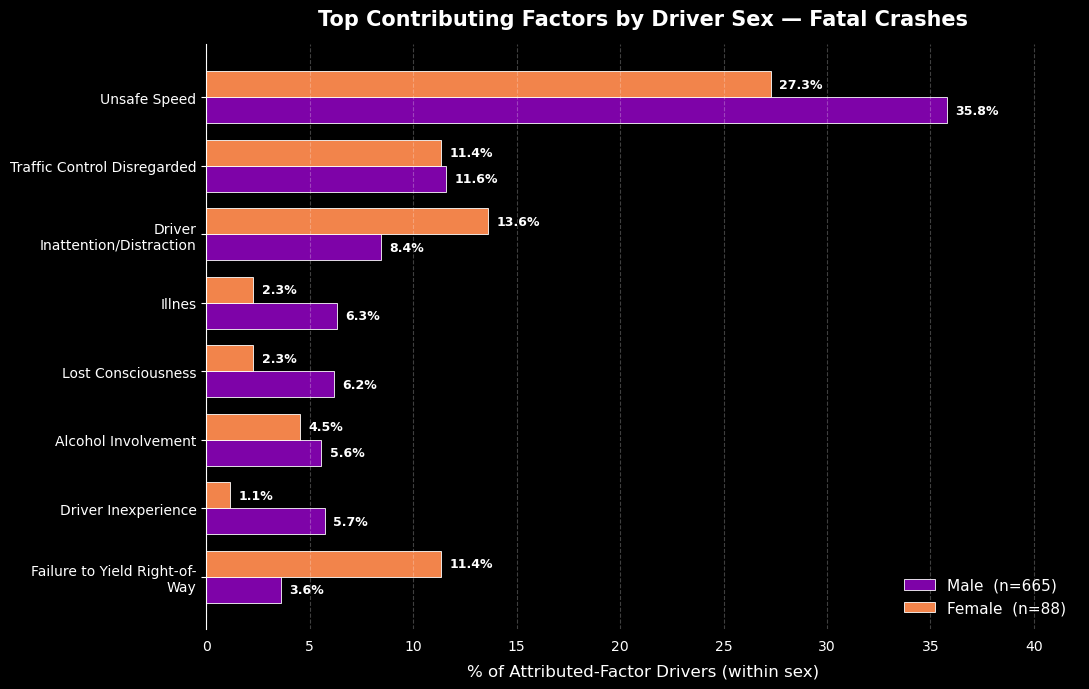

In [9]:
import textwrap
import pandas as pd
import matplotlib.pyplot as plt

fatal_ids = set(merg_df["COLLISION_ID"].unique())
vehicles = pd.read_csv(
    "datasets/Motor_Vehicle_Collisions_-_Vehicles_20260424.csv",
    usecols=["COLLISION_ID", "DRIVER_SEX", "CONTRIBUTING_FACTOR_1"],
)
veh = vehicles[
    vehicles["COLLISION_ID"].isin(fatal_ids)
    & vehicles["DRIVER_SEX"].isin(["M", "F"])
    & vehicles["CONTRIBUTING_FACTOR_1"].notna()
    & (vehicles["CONTRIBUTING_FACTOR_1"] != "Unspecified")
]
del vehicles

top_factors = veh["CONTRIBUTING_FACTOR_1"].value_counts().head(8).index.tolist()
ct = (
    veh[veh["CONTRIBUTING_FACTOR_1"].isin(top_factors)]
    .groupby(["CONTRIBUTING_FACTOR_1", "DRIVER_SEX"], observed=True)
    .size()
    .unstack(fill_value=0)
    .loc[top_factors, ["M", "F"]]
)
totals = veh.groupby("DRIVER_SEX", observed=True).size()  # attributed-factor drivers per sex
prop = ct.div(totals[["M", "F"]], axis=1) * 100

male_color = plt.cm.plasma(0.25)
female_color = plt.cm.plasma(0.70)
labels = [textwrap.fill(f, 28) for f in top_factors]

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(11, 7))
    y = list(range(len(top_factors)))
    h = 0.38

    bars_m = ax.barh(
        [i + h / 2 for i in y], prop["M"], h,
        label=f"Male  (n={int(totals['M']):,})", color=male_color,
        edgecolor="white", linewidth=0.6,
    )
    bars_f = ax.barh(
        [i - h / 2 for i in y], prop["F"], h,
        label=f"Female  (n={int(totals['F']):,})", color=female_color,
        edgecolor="white", linewidth=0.6,
    )

    for bars in (bars_m, bars_f):
        for b in bars:
            w = b.get_width()
            ax.text(
                w + 0.4, b.get_y() + b.get_height() / 2,
                f"{w:.1f}%", va="center", ha="left",
                fontsize=9, color="white", fontweight="bold",
            )

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel("% of Attributed-Factor Drivers (within sex)", fontsize=12, labelpad=8)
    ax.set_title(
        "Top Contributing Factors by Driver Sex — Fatal Crashes",
        fontsize=15, fontweight="bold", pad=14,
    )
    ax.set_xlim(0, prop.values.max() * 1.18)
    ax.grid(axis="x", linestyle="--", alpha=0.25)
    for s in ("top", "right", "bottom"):
        ax.spines[s].set_visible(False)
    ax.tick_params(bottom=False)
    ax.legend(frameon=False, fontsize=11, loc="lower right")

    plt.tight_layout()
    plt.show()